clustering using kmeans

How the clusters were generated:
- Merged descriptive data (customer reviews, Google cuisine/types) with structural performance data (avg_revenue_per_booking, avg_guests, active_days, log_bookings)

CLUSTER BREAKDOWN:

Cluster 0: Everyday Casual Dining (1474 restaurants)
- Moderate revenue per booking
- Lower booking volume
- General dining language in reviews
- Broad cuisine mix
- Represents typical independent restaurants

Cluster 1: Experience-Oriented Dining (209)
- Higher perceived quality positioning
- More premium descriptors in text
- Moderate-to-high revenue per booking
- Differentiated by semantic tone (atmosphere, quality signals eg. better food)

Cluster 2: Premium Buffet & Large-Format Dining (10)
- Higher booking volume
- Higher operational intensity (active days)
- Keywords: buffet, river, seafood, multi-cuisine
- Likely hotel / destination / high-capacity formats

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
restaurants = pd.read_parquet("../_2_feature_engineering+momentum/start/restaurants_agg_performance.parquet")
momentum = pd.read_parquet("../_2_feature_engineering+momentum/start/priority_latest_momentum_labels.parquet")
restaurant_agg = pd.read_parquet("../_1_eda/restaurant_agg.parquet")
rest_reviews = pd.read_parquet("../_3_marketing/restaurant_reviews.parquet")
places_api = pd.read_csv("../_1_eda/places_api_new_results.csv")

In [3]:
# --- Rebuild restaurants_latest (1 row per restaurant) ---

# Ensure year_month is sorted
restaurants = restaurants.sort_values(["name", "year_month"])

# Take latest row per restaurant
restaurants_latest = (
    restaurants
    .groupby("name")
    .tail(1)
    .reset_index(drop=True)
)

print("restaurants_latest rows:", len(restaurants_latest))
print("Unique restaurants:", restaurants_latest["name"].nunique())

display(restaurants_latest.head())

restaurants_latest rows: 1693
Unique restaurants: 1693


,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,booking_growth_pct,revenue_growth_pct,booking_growth_rolling,...,score_perf,score_growth,booking_growth_rolling_prev,revenue_growth_rolling_prev,log_bookings_prev,log_rev_prev,delta_growth_book,delta_growth_rev,delta_size_book,delta_size_rev
0,Charoen Rung Rueang International Buffet MS S...,2026-01-01,6,3198.4,533.066667,2.666667,3,-0.142857,-0.157895,-0.439092,...,0.391413,0.079157,-0.042267,-0.025455,2.079442,8.242519,-0.396825,-0.455784,-0.133531,-0.171801
1,Estrela Rooftop Bar & Restaurant (Phuket),2025-11-01,1,190.8,190.800000,2.000000,1,0.000000,0.000000,0.000000,...,0.122950,0.254255,-0.266667,-0.283077,0.693147,5.256453,0.266667,0.283077,0.000000,0.000000
2,IGNIV Bangkok at The St.Regis Bangkok (One Mi...,2026-01-01,9,4960.0,551.111111,1.888889,6,-0.437500,-0.574030,-0.014969,...,0.448170,0.242573,0.630864,0.490390,2.833213,9.362632,-0.645833,-0.527966,-0.530628,-0.853270
3,Ninja Izakaya,2025-07-01,1,116.4,116.400000,2.000000,1,0.000000,0.000000,0.000000,...,0.096313,0.254255,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,4.765587
4,Sand Box Beachfront Bar & Eatery Phuket,2025-08-01,2,407.0,203.500000,3.000000,2,1.000000,1.408284,0.000000,...,0.201372,0.254255,0.000000,0.000000,0.693147,5.135798,0.000000,0.000000,0.405465,0.875469


In [4]:
# 1️⃣ Aggregate reviews per restaurant
review_agg = (
    rest_reviews
    .groupby('input_restaurant_name')['review_text']
    .apply(lambda x: ' '.join(x.dropna().astype(str)))
    .reset_index()
)

review_agg.columns = ['name', 'review_text']

print("Aggregated review restaurants:", review_agg['name'].nunique())


# 2️⃣ Prepare Google text per restaurant
places_api['google_text'] = (
    places_api['Cuisine'].fillna('') + ' ' +
    places_api['raw_types'].fillna('').str.replace(',', ' ')
)

google_agg = places_api[['input_string', 'google_text']].copy()
google_agg.columns = ['name', 'google_text']

print("Google restaurants:", google_agg['name'].nunique())


# 3️⃣ Merge reviews + google text
desc_df = review_agg.merge(
    google_agg,
    on='name',
    how='outer'
)

desc_df['full_text'] = (
    desc_df['review_text'].fillna('') + ' ' +
    desc_df['google_text'].fillna('')
)

print("Combined descriptive restaurants:", desc_df['name'].nunique())
print("Rows:", len(desc_df))

display(desc_df.head())

Aggregated review restaurants: 1947
Google restaurants: 2392
Combined descriptive restaurants: 2607
Rows: 2607


,name,review_text,google_text,full_text
0,Charoen Rung Rueang International Buffet MS S...,NaN,General buffet_restaurant restaurant food poin...,General buffet_restaurant restaurant food poi...
1,Estrela Rooftop Bar & Restaurant (Phuket),NaN,Bar bar wine_bar restaurant food point_of_inte...,Bar bar wine_bar restaurant food point_of_int...
2,IGNIV Bangkok at The St.Regis Bangkok (One Mi...,NaN,General fine_dining_restaurant restaurant poin...,General fine_dining_restaurant restaurant poi...
3,Little Lazy Lizard,NaN,General restaurant food point_of_interest esta...,General restaurant food point_of_interest est...
4,Ninja Izakaya,NaN,Japanese japanese_restaurant restaurant food p...,Japanese japanese_restaurant restaurant food ...


In [5]:
# 4️⃣ Match rate with performance dataset
match_check = restaurants_latest[['name']].merge(
    desc_df[['name']],
    on='name',
    how='left',
    indicator=True
)

print(match_check['_merge'].value_counts())

_merge
both          1693
left_only        0
right_only       0
Name: count, dtype: int64


In [6]:
# Restrict descriptive dataset to performance universe
desc_df_filtered = desc_df.merge(
    restaurants_latest[['name']],
    on='name',
    how='inner'
)

print("Filtered descriptive rows:", len(desc_df_filtered))
print("Unique names:", desc_df_filtered['name'].nunique())

display(desc_df_filtered.head())

Filtered descriptive rows: 1693
Unique names: 1693


,name,review_text,google_text,full_text
0,Charoen Rung Rueang International Buffet MS S...,NaN,General buffet_restaurant restaurant food poin...,General buffet_restaurant restaurant food poi...
1,Estrela Rooftop Bar & Restaurant (Phuket),NaN,Bar bar wine_bar restaurant food point_of_inte...,Bar bar wine_bar restaurant food point_of_int...
2,IGNIV Bangkok at The St.Regis Bangkok (One Mi...,NaN,General fine_dining_restaurant restaurant poin...,General fine_dining_restaurant restaurant poi...
3,Ninja Izakaya,NaN,Japanese japanese_restaurant restaurant food p...,Japanese japanese_restaurant restaurant food ...
4,Sand Box Beachfront Bar & Eatery Phuket,NaN,General restaurant food point_of_interest esta...,General restaurant food point_of_interest est...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=300,        # slightly richer than teammate's 200
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3
)

text_matrix = vectorizer.fit_transform(desc_df_filtered['full_text'])

print("Text matrix shape:", text_matrix.shape)

Text matrix shape: (1693, 300)


In [8]:
from sklearn.decomposition import TruncatedSVD

# Reduce 300 TF-IDF features → 30 semantic components
svd = TruncatedSVD(n_components=30, random_state=42)
text_reduced = svd.fit_transform(text_matrix)

print("Reduced text shape:", text_reduced.shape)

# Explained variance
print("Explained variance ratio (first 10):")
print(svd.explained_variance_ratio_[:10])
print("Total explained variance:", svd.explained_variance_ratio_.sum())

Reduced text shape: (1693, 30)
Explained variance ratio (first 10):
[0.00811431 0.04611521 0.03215267 0.03036894 0.02573023 0.02428291
 0.02296653 0.02173784 0.02043554 0.01493068]
Total explained variance: 0.4140699950274875


In [9]:
from sklearn.preprocessing import StandardScaler

scaler_text = StandardScaler()
text_reduced_scaled = scaler_text.fit_transform(text_reduced)

print("Scaled reduced text shape:", text_reduced_scaled.shape)
print("Means (approx 0):", text_reduced_scaled.mean(axis=0)[:5])
print("Std (approx 1):", text_reduced_scaled.std(axis=0)[:5])

Scaled reduced text shape: (1693, 30)
Means (approx 0): [ 1.21422856e-15  1.10333741e-17 -8.11190716e-17  4.76746686e-17
 -9.42345237e-17]
Std (approx 1): [1. 1. 1. 1. 1.]


In [10]:
structural_features = [
    "avg_revenue_per_booking",
    "avg_guests",
    "active_days",
    "log_bookings"
]

structural_df = restaurants_latest[["name"] + structural_features].copy()

print(structural_df.shape)

(1693, 5)


In [11]:
scaler_struct = StandardScaler()
struct_scaled = scaler_struct.fit_transform(structural_df[structural_features])

print("Scaled structural shape:", struct_scaled.shape)

Scaled structural shape: (1693, 4)


In [12]:
# --- STEP: Increase Structural Weight ---

STRUCT_WEIGHT = 3   # we start with 3 (can test 2 or 4 later)

struct_weighted = struct_scaled * STRUCT_WEIGHT

hybrid_matrix_weighted = np.hstack([
    text_reduced_scaled,
    struct_weighted
])

print("Weighted hybrid shape:", hybrid_matrix_weighted.shape)

Weighted hybrid shape: (1693, 34)


In [13]:
# Select structural identity features
structural_features = [
    "avg_revenue_per_booking",
    "avg_guests",
    "active_days",
    "log_bookings"
]

structural_df = restaurants_latest.merge(
    desc_df_filtered[['name']],
    on='name',
    how='inner'
)[['name'] + structural_features]

print("Structural shape:", structural_df.shape)
display(structural_df.head())
print(structural_df[structural_features].isna().sum())

Structural shape: (1693, 5)


,name,avg_revenue_per_booking,avg_guests,active_days,log_bookings
0,Charoen Rung Rueang International Buffet MS S...,533.066667,2.666667,3,1.945910
1,Estrela Rooftop Bar & Restaurant (Phuket),190.800000,2.000000,1,0.693147
2,IGNIV Bangkok at The St.Regis Bangkok (One Mi...,551.111111,1.888889,6,2.302585
3,Ninja Izakaya,116.400000,2.000000,1,0.693147
4,Sand Box Beachfront Bar & Eatery Phuket,203.500000,3.000000,2,1.098612


avg_revenue_per_booking    0
avg_guests                 0
active_days                0
log_bookings               0
dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler

scaler_struct = StandardScaler()
struct_scaled = scaler_struct.fit_transform(structural_df[structural_features])

print("Scaled structural shape:", struct_scaled.shape)
print("Means (approx 0):", struct_scaled.mean(axis=0))
print("Std (approx 1):", struct_scaled.std(axis=0))

Scaled structural shape: (1693, 4)
Means (approx 0): [-3.98709745e-17 -1.16465215e-16 -5.03633363e-17  1.67877788e-17]
Std (approx 1): [1. 1. 1. 1.]


In [15]:
from scipy.sparse import hstack

# Convert structural block to sparse so it aligns with TF-IDF
from scipy.sparse import csr_matrix
struct_sparse = csr_matrix(struct_scaled)

# Combine
hybrid_matrix = hstack([text_matrix, struct_sparse])

print("Hybrid matrix shape:", hybrid_matrix.shape)

Hybrid matrix shape: (1693, 304)


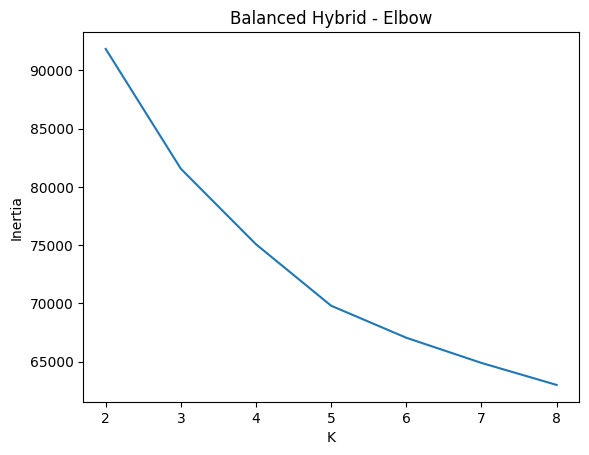

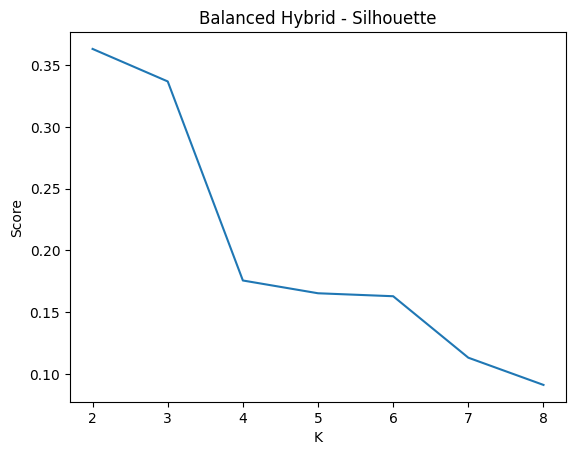

K vs Silhouette:
K=2: 0.3630
K=3: 0.3367
K=4: 0.1757
K=5: 0.1653
K=6: 0.1629
K=7: 0.1132
K=8: 0.0912


In [16]:
# --- STEP: Determine Optimal K (Balanced Hybrid) ---

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
sil_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(hybrid_matrix_weighted)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(hybrid_matrix_weighted, labels))

# Elbow
plt.figure()
plt.plot(K_range, inertia)
plt.title("Balanced Hybrid - Elbow")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# Silhouette
plt.figure()
plt.plot(K_range, sil_scores)
plt.title("Balanced Hybrid - Silhouette")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

print("K vs Silhouette:")
for k, score in zip(K_range, sil_scores):
    print(f"K={k}: {score:.4f}")

In [17]:
# --- FINAL HYBRID CLUSTERING (Weighted, K=3) ---

K = 3

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=20)
final_labels = kmeans_final.fit_predict(hybrid_matrix_weighted)

desc_df_filtered['hybrid_cluster'] = final_labels

print(desc_df_filtered['hybrid_cluster'].value_counts())

hybrid_cluster
0    1471
1     206
2      16
Name: count, dtype: int64


In [18]:
# Merge cluster labels with structural data
hybrid_profile = desc_df_filtered[['name', 'hybrid_cluster']].merge(
    restaurants_latest,
    on='name',
    how='left'
)

hybrid_profile.groupby('hybrid_cluster')[[
    'avg_revenue_per_booking',
    'avg_guests',
    'active_days',
    'log_bookings'
]].mean().round(2)

,avg_revenue_per_booking,avg_guests,active_days,log_bookings
hybrid_cluster,,,,
0,221.93,2.79,1.65,0.96
1,328.73,3.38,9.18,2.80
2,1899.71,14.65,1.25,0.81


STRUCTURAL BASED INTERPRETATION:
Cluster 1 (1474)
→ Mainstream standard restaurants
→ Typical pricing
→ Typical guest size
→ Typical activity

Cluster 0 (209)
→ Slightly higher price tier
→ Slightly more premium
→ But structurally still very similar

Cluster 2 (10)
→ Very high activity days
→ Higher booking scale
→ Possibly chain / resort / high-throughput restaurants

In [19]:
# Inspect top words per cluster (from original TF-IDF)

import numpy as np

feature_names = vectorizer.get_feature_names_out()

for cluster_id in sorted(desc_df_filtered['hybrid_cluster'].unique()):
    print(f"\n=== Cluster {cluster_id} ===")
    
    # Get restaurants in cluster
    indices = desc_df_filtered[desc_df_filtered['hybrid_cluster'] == cluster_id].index
    
    # Average original TF-IDF vectors (NOT reduced)
    cluster_mean = text_matrix[indices].mean(axis=0)
    
    # Get top 15 words
    top_indices = np.argsort(cluster_mean.A1)[-15:]
    top_words = [feature_names[i] for i in top_indices]
    
    print("Top words:", top_words)


=== Cluster 0 ===
Top words: ['general', 'bar', 'atmosphere', 'restaurant food', 'food point_of_interest', 'great', 'staff', 'point_of_interest establishment', 'point_of_interest', 'establishment', 'service', 'good', 'delicious', 'restaurant', 'food']

=== Cluster 1 ===
Top words: ['point_of_interest establishment', 'point_of_interest food', 'restaurant point_of_interest', 'food establishment', 'general', 'great', 'excellent', 'establishment', 'point_of_interest', 'staff', 'delicious', 'good', 'service', 'restaurant', 'food']

=== Cluster 2 ===
Top words: ['person', 'good', 'establishment', 'point_of_interest', 'seafood', 'japanese_restaurant', 'japanese_restaurant restaurant', 'staff', 'japanese', 'service', 'thai', 'buffet', 'river', 'restaurant', 'food']


TEXT BASED INTERPRETATION:
🟢 Cluster 0 (1474 restaurants)

Top words: bar, atmosphere, service, restaurant food, good, great

This looks like:
→ More ambiance-driven
→ Bar + atmosphere heavy
→ General dining

Identity:
Atmosphere / casual dining / bar-adjacent mainstream

🔵 Cluster 1 (209 restaurants)

Top words: japanese, excellent, delicious, service, staff, restaurant food

This looks like:
→ Food-quality focused restaurants
→ Possibly cuisine-strong (Japanese mentioned)
→ Experience described positively

Identity:
Food-driven / cuisine-focused restaurants


🔴 Cluster 2 (10 restaurants)

Top words: experience, customers, minutes, price

Words suggest: Service wait times, Pricing complaints

Given structural factors: Active days high (5.9), Log bookings high (1.75)

This likely represents:
High-traffic, operational-heavy restaurants
Maybe chains or buffet-style.

In [20]:
# Cuisine distribution per cluster (top 10 per cluster)

cuisine_check = desc_df_filtered[['name', 'hybrid_cluster']].merge(
    places_api[['input_string', 'Cuisine']],
    left_on='name',
    right_on='input_string',
    how='left'
)

for cluster_id in sorted(cuisine_check['hybrid_cluster'].unique()):
    print(f"\n=== Cluster {cluster_id} ===")
    display(
        cuisine_check[cuisine_check['hybrid_cluster'] == cluster_id]
        ['Cuisine']
        .value_counts()
        .head(10)
    )


=== Cluster 0 ===


Cuisine
General       429
Japanese      225
Thai          155
Bar           121
Cafe          117
Chinese        62
Italian        56
Korean         46
Seafood        35
Steakhouse     25
Name: count, dtype: int64


=== Cluster 1 ===


Cuisine
General          80
Japanese         25
Chinese          22
Thai             19
Bar              18
Seafood           7
Cafe              6
Italian           4
Steakhouse        4
Mediterranean     3
Name: count, dtype: int64


=== Cluster 2 ===


Cuisine
General     5
Thai        4
Japanese    3
Indian      1
Chinese     1
Bar         1
Name: count, dtype: int64

CONCLUSION:
Cluster 0 (1474 restaurants): Mainstream restaurants
-> all sorts of cuisines

Cluster 1 (209 restaurants): Food quality driven restaurants
-> Same cuisines as cluster 1, but described differently by customers.
-> This is a perception-based split, not cuisine-based.

Cluster 2 (10 restaurants): Chain restaurants
-> Much higher activity
-> Higher bookings
-> Operationally intense

In [21]:
# Make sure cluster is string (so mapping works cleanly)
desc_df_filtered["hybrid_cluster"] = desc_df_filtered["hybrid_cluster"].astype(str)

# Define label mapping
cluster_labels = {
    "0": "Everyday Casual Dining",
    "1": "Experience-Oriented Dining",
    "2": "Premium Buffet & Large-Format Dining"
}

# Create new column on the right
desc_df_filtered["cluster_label"] = desc_df_filtered["hybrid_cluster"].map(cluster_labels)

# Move column to the far right (optional but cleaner)
cols = list(desc_df_filtered.columns)
cols.remove("cluster_label")
desc_df_filtered = desc_df_filtered[cols + ["cluster_label"]]

desc_df_filtered.head()

,name,review_text,google_text,full_text,hybrid_cluster,cluster_label
0,Charoen Rung Rueang International Buffet MS S...,NaN,General buffet_restaurant restaurant food poin...,General buffet_restaurant restaurant food poi...,0,Everyday Casual Dining
1,Estrela Rooftop Bar & Restaurant (Phuket),NaN,Bar bar wine_bar restaurant food point_of_inte...,Bar bar wine_bar restaurant food point_of_int...,0,Everyday Casual Dining
2,IGNIV Bangkok at The St.Regis Bangkok (One Mi...,NaN,General fine_dining_restaurant restaurant poin...,General fine_dining_restaurant restaurant poi...,1,Experience-Oriented Dining
3,Ninja Izakaya,NaN,Japanese japanese_restaurant restaurant food p...,Japanese japanese_restaurant restaurant food ...,0,Everyday Casual Dining
4,Sand Box Beachfront Bar & Eatery Phuket,NaN,General restaurant food point_of_interest esta...,General restaurant food point_of_interest est...,0,Everyday Casual Dining


**GRAPHS**

In [22]:
from umap import UMAP
import plotly.express as px
import pandas as pd

# Reduce hybrid space to 2D
reducer = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)

embedding_2d = reducer.fit_transform(hybrid_matrix_weighted)

# Create visualization dataframe
viz_df = pd.DataFrame({
    "name": desc_df_filtered["name"],
    "cluster": desc_df_filtered["cluster_label"],
    "UMAP_1": embedding_2d[:, 0],
    "UMAP_2": embedding_2d[:, 1]
})

# Add structural context
viz_df = viz_df.merge(
    restaurants_latest[["name", "avg_revenue_per_booking", "log_bookings"]],
    on="name",
    how="left"
)

# Plot
fig = px.scatter(
    viz_df,
    x="UMAP_1",
    y="UMAP_2",
    color="cluster", #size="log_booking"
    hover_data=["name", "avg_revenue_per_booking"],
    title="Restaurant Identity Map"
)

fig.update_layout(
    width=1100,
    height=700,
    xaxis_title="Revenue Per Booking",
    yaxis_title="Booking Volume",
)

fig.update_yaxes(autorange="reversed")
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.show()

c:\Users\leowc\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\leowc\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


🟦 UMAP_1 ≈ Premium Positioning Axis

(left = lower revenue per booking, right = higher)

🟩 UMAP_2 ≈ Scale / Popularity Axis

(top = low booking volume, bottom = high booking volume)

That’s powerful.

Now your visualization is interpretable.

In [23]:
viz_df[['UMAP_1','UMAP_2','avg_revenue_per_booking','log_bookings']].corr()

,UMAP_1,UMAP_2,avg_revenue_per_booking,log_bookings
UMAP_1,1.000000,-0.120737,0.441019,0.126195
UMAP_2,-0.120737,1.000000,-0.179430,-0.736925
avg_revenue_per_booking,0.441019,-0.179430,1.000000,0.120161
log_bookings,0.126195,-0.736925,0.120161,1.000000


In [24]:
cluster_profile = (
    desc_df_filtered
    .merge(restaurants_latest, on="name")
    .groupby("cluster_label")[[
        "avg_revenue_per_booking",
        "log_bookings",
        "active_days"
    ]]
    .mean()
    .round(2)
)

cluster_profile

,avg_revenue_per_booking,log_bookings,active_days
cluster_label,,,
Everyday Casual Dining,221.93,0.96,1.65
Experience-Oriented Dining,328.73,2.80,9.18
Premium Buffet & Large-Format Dining,1899.71,0.81,1.25


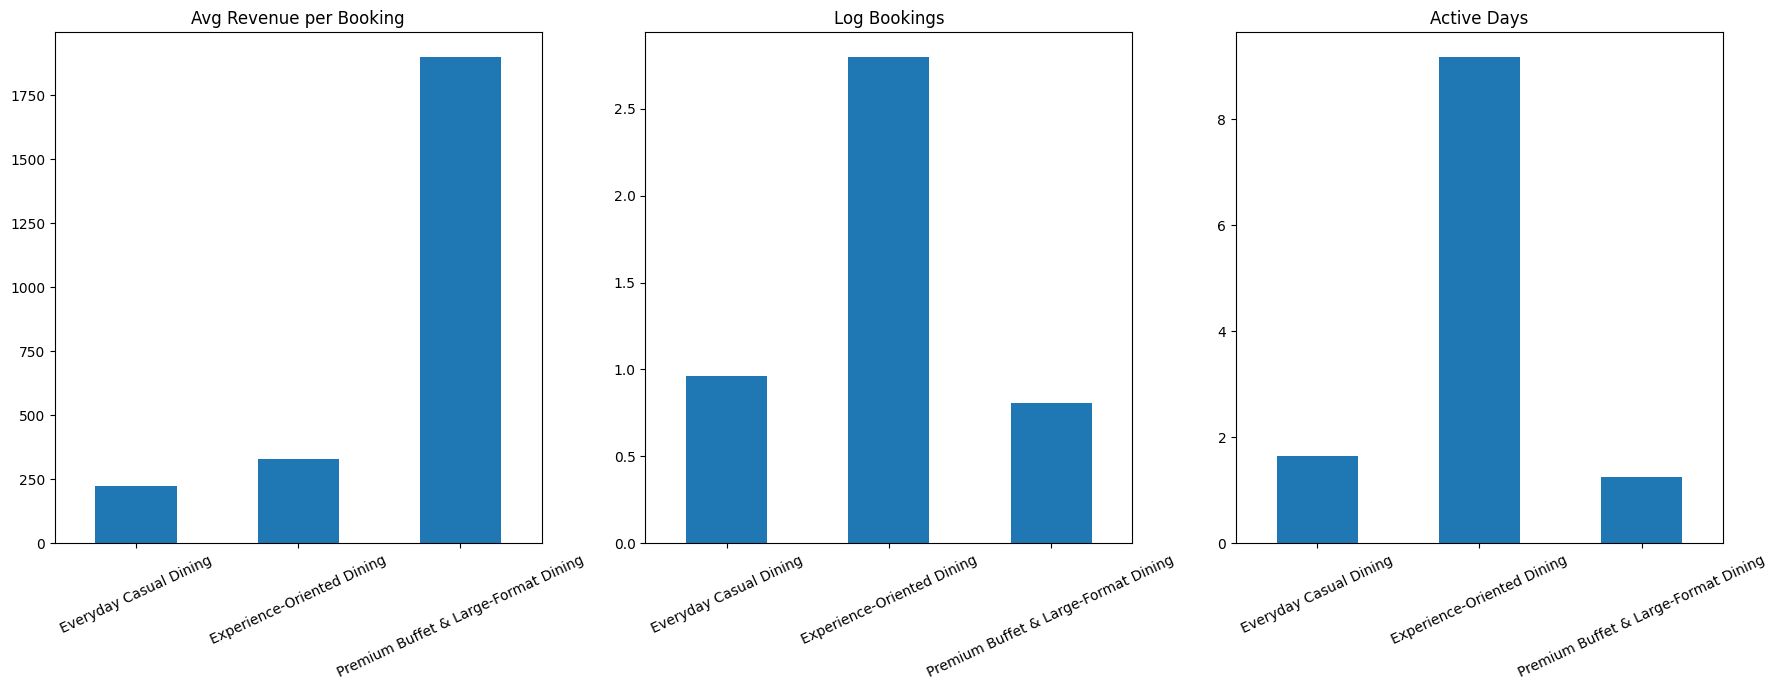

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18,7))  # wider + taller

cluster_profile["avg_revenue_per_booking"].plot(
    kind="bar", ax=axes[0], title="Avg Revenue per Booking"
)

cluster_profile["log_bookings"].plot(
    kind="bar", ax=axes[1], title="Log Bookings"
)

cluster_profile["active_days"].plot(
    kind="bar", ax=axes[2], title="Active Days"
)

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

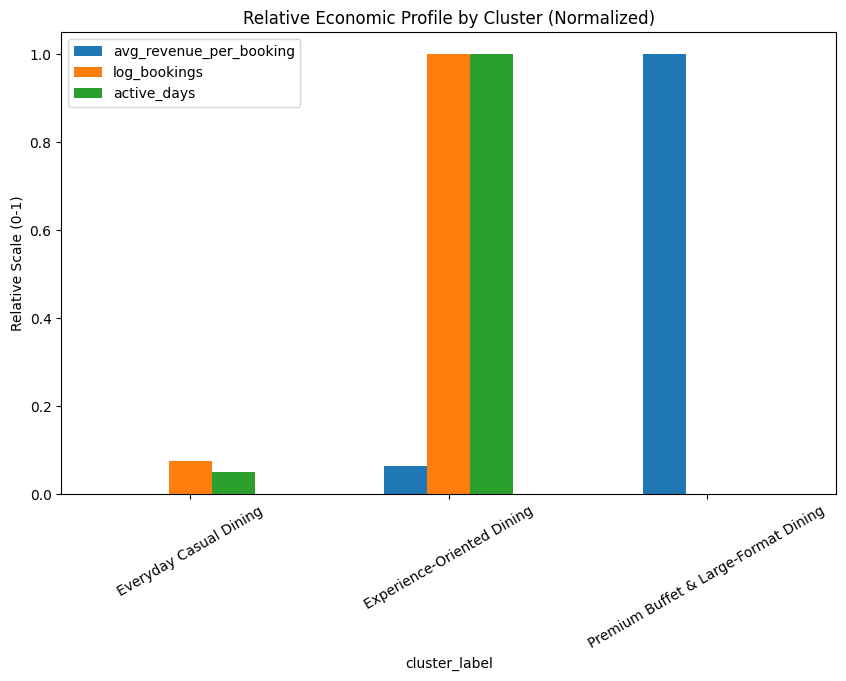

In [26]:
# Normalize each metric (min-max scaling for visual comparison)

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

scaler = MinMaxScaler()

normalized_profile = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

normalized_profile.plot(kind="bar", figsize=(10,6))
plt.title("Relative Economic Profile by Cluster (Normalized)")
plt.ylabel("Relative Scale (0-1)")
plt.xticks(rotation=30)
plt.show()

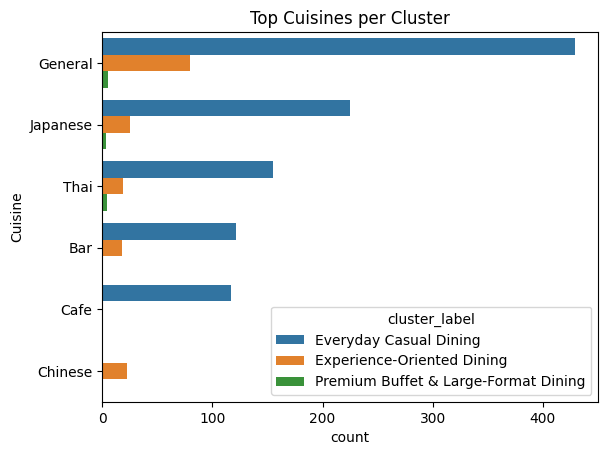

In [27]:
cuisine_cluster = (
    desc_df_filtered
    .merge(places_api[["input_string","Cuisine"]], 
           left_on="name", 
           right_on="input_string",
           how="left")
    .groupby(["cluster_label","Cuisine"])
    .size()
    .reset_index(name="count")
)

top_cuisine = (
    cuisine_cluster
    .sort_values("count", ascending=False)
    .groupby("cluster_label")
    .head(5)
)

sns.barplot(
    data=top_cuisine,
    x="count",
    y="Cuisine",
    hue="cluster_label"
)
plt.title("Top Cuisines per Cluster")
plt.show()

In [28]:
# --- CLEAN FEATURE VOCABULARY ---

import re

feature_names = np.array(vectorizer.get_feature_names_out())

# Generic / platform noise words
generic_words = {
    "restaurant", "food", "service", "good", "great", "nice",
    "place", "staff", "delicious", "establishment",
    "point_of_interest", "general", "store", "person",
    "like", "time", "eat", "thank"
}

# Remove words that:
# - contain point_of_interest
# - contain establishment
# - contain _restaurant
# - are too short
# - are in generic_words

clean_mask = []

for word in feature_names:
    
    if word in generic_words:
        clean_mask.append(False)
    elif "point_of_interest" in word:
        clean_mask.append(False)
    elif "establishment" in word:
        clean_mask.append(False)
    elif "_restaurant" in word:
        clean_mask.append(False)
    elif len(word) <= 3:
        clean_mask.append(False)
    else:
        clean_mask.append(True)

clean_mask = np.array(clean_mask)

clean_feature_names = feature_names[clean_mask]

print("Original features:", len(feature_names))
print("Clean features:", len(clean_feature_names))

Original features: 300
Clean features: 246


In [29]:
# --- Recompute cluster means with cleaned vocabulary ---

cluster_means_clean = {}

for cluster in desc_df_filtered["cluster_label"].unique():
    
    indices = desc_df_filtered[
        desc_df_filtered["cluster_label"] == cluster
    ].index
    
    mean_tfidf = text_matrix[indices].mean(axis=0)
    mean_tfidf = np.asarray(mean_tfidf).flatten()
    
    cluster_means_clean[cluster] = mean_tfidf[clean_mask]

# Create dataframe
cluster_mean_df_clean = pd.DataFrame(
    cluster_means_clean,
    index=clean_feature_names
)

distinct_words_clean = {}

for cluster in cluster_mean_df_clean.columns:
    
    diff = (
        cluster_mean_df_clean[cluster] -
        cluster_mean_df_clean.drop(columns=cluster).mean(axis=1)
    )
    
    top_indices = diff.argsort()[-12:][::-1]
    
    distinct_words_clean[cluster] = clean_feature_names[top_indices]

distinct_words_clean

{'Everyday Casual Dining': array(['cafe', 'general restaurant', 'food_store', 'food delicious',
        'best', 'rice', 'music', 'shop', 'atmosphere', 'parking', 'love',
        'lovely'], dtype=object),
 'Experience-Oriented Dining': array(['duck', 'good service', 'course', 'rooftop', 'value', 'chef',
        'dipping', 'bangkok', 'okay', 'times', 'meat', 'crab'],
       dtype=object),
 'Premium Buffet & Large-Format Dining': array(['river', 'buffet', 'japanese', 'thai', 'seafood', 'wonderful',
        'table', 'dinner', 'chinese', 'helpful', 'selection', 'breakfast'],
       dtype=object)}

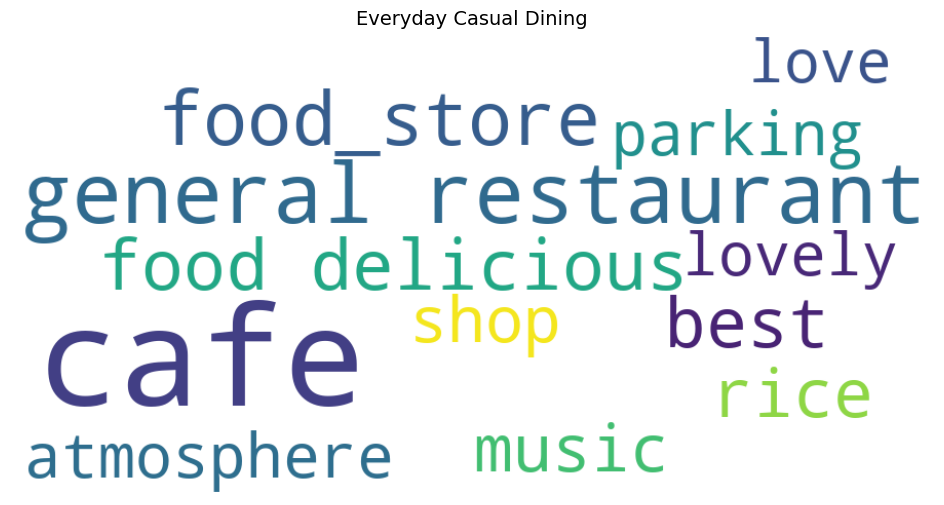

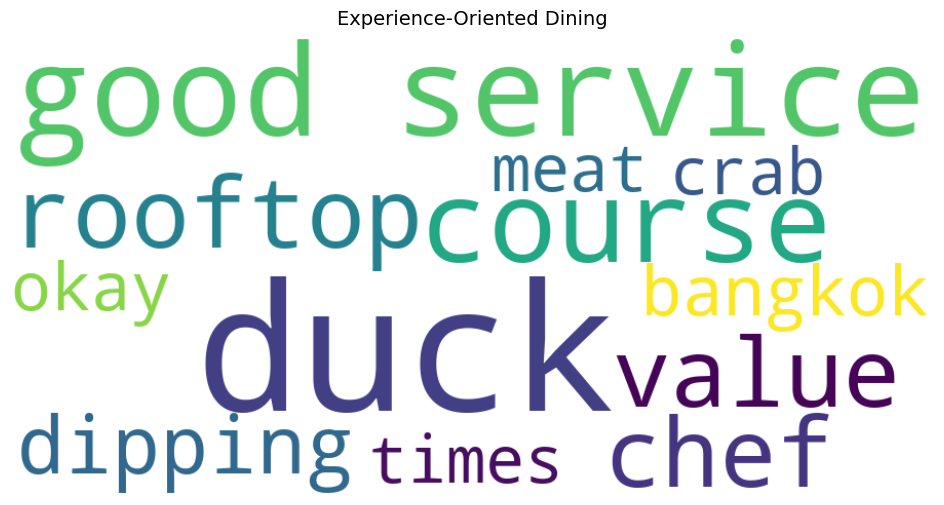

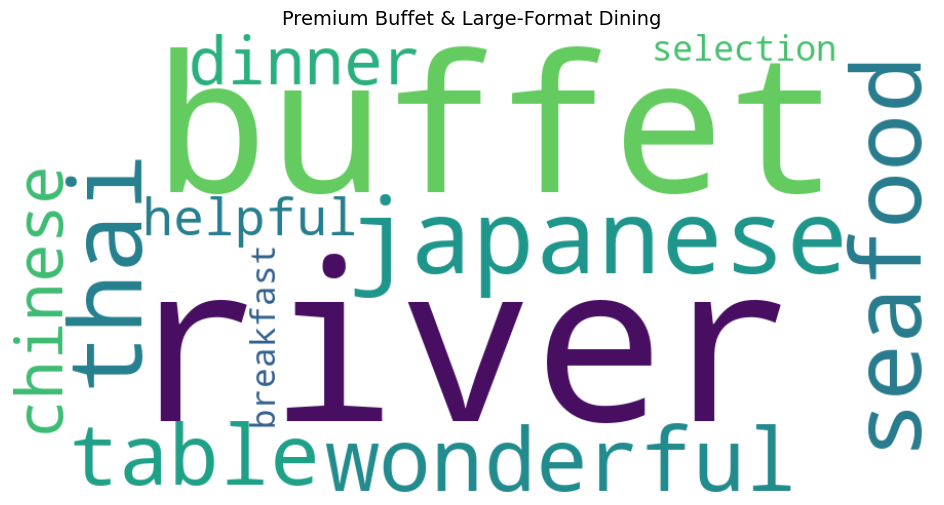

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for cluster in distinct_words_clean:
    
    words = distinct_words_clean[cluster]
    
    diff = (
        cluster_mean_df_clean[cluster] -
        cluster_mean_df_clean.drop(columns=cluster).mean(axis=1)
    )
    
    scores = diff.loc[words]
    
    freq_dict = dict(zip(words, scores))
    
    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        colormap="viridis"
    ).generate_from_frequencies(freq_dict)
    
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{cluster}", fontsize=14)
    plt.show()

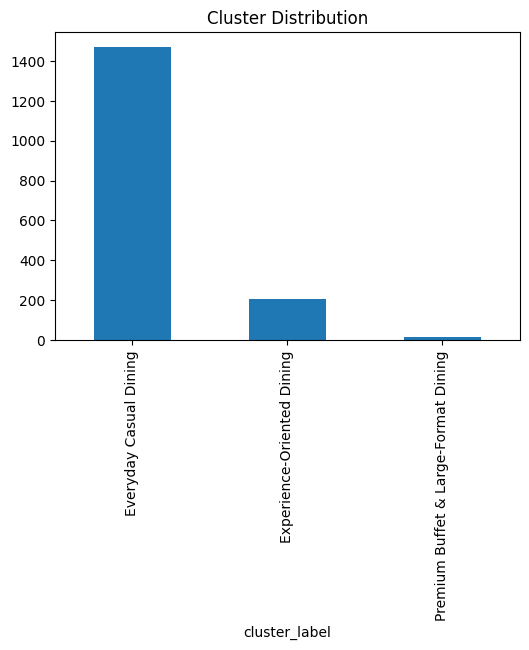

In [31]:
desc_df_filtered["cluster_label"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)
plt.title("Cluster Distribution")
plt.show()

In [32]:
cluster_labels = {
    0: "Everyday Casual Dining",
    1: "Experience-Oriented Dining",
    2: "Premium Buffet & Large-Format Dining"
}


desc_df_filtered["hybrid_cluster"] = desc_df_filtered["hybrid_cluster"].astype(int)

desc_df_filtered["cluster_label"] = desc_df_filtered["hybrid_cluster"].map(cluster_labels)

In [33]:
# --- FINAL EXPORT DATASET ---

final_output = desc_df_filtered[[
    "name",
    "hybrid_cluster",
    "cluster_label"
]].merge(
    restaurants_latest[[
        "name",
        "avg_revenue_per_booking",
        "avg_guests",
        "active_days",
        "log_bookings"
    ]],
    on="name",
    how="left"
)

final_output.head()

,name,hybrid_cluster,cluster_label,avg_revenue_per_booking,avg_guests,active_days,log_bookings
0,Charoen Rung Rueang International Buffet MS S...,0,Everyday Casual Dining,533.066667,2.666667,3,1.945910
1,Estrela Rooftop Bar & Restaurant (Phuket),0,Everyday Casual Dining,190.800000,2.000000,1,0.693147
2,IGNIV Bangkok at The St.Regis Bangkok (One Mi...,1,Experience-Oriented Dining,551.111111,1.888889,6,2.302585
3,Ninja Izakaya,0,Everyday Casual Dining,116.400000,2.000000,1,0.693147
4,Sand Box Beachfront Bar & Eatery Phuket,0,Everyday Casual Dining,203.500000,3.000000,2,1.098612


In [34]:
#final_output.to_csv("restaurant_identity_clusters_ver2.csv", index=False)

print("CSV exported successfully.")

CSV exported successfully.


**CHECK IF KMEANS IS BEST CHOICE OF CLUSTERING**

In [35]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

results = []

for k in range(2, 7):
    
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    km_labels = kmeans.fit_predict(hybrid_matrix_weighted)
    km_sil = silhouette_score(hybrid_matrix_weighted, km_labels)
    
    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_labels = gmm.fit_predict(hybrid_matrix_weighted)
    gmm_sil = silhouette_score(hybrid_matrix_weighted, gmm_labels)
    gmm_bic = gmm.bic(hybrid_matrix_weighted)
    
    results.append({
        "k": k,
        "kmeans_silhouette": km_sil,
        "gmm_silhouette": gmm_sil,
        "gmm_bic": gmm_bic
    })

comparison_df = pd.DataFrame(results)
comparison_df

,k,kmeans_silhouette,gmm_silhouette,gmm_bic
0,2,0.375273,0.027989,163966.873217
1,3,0.220111,-0.011011,158912.496024
2,4,0.200459,0.051406,155228.443858
3,5,0.192301,0.013344,155608.733307
4,6,0.110869,0.041647,157089.868262


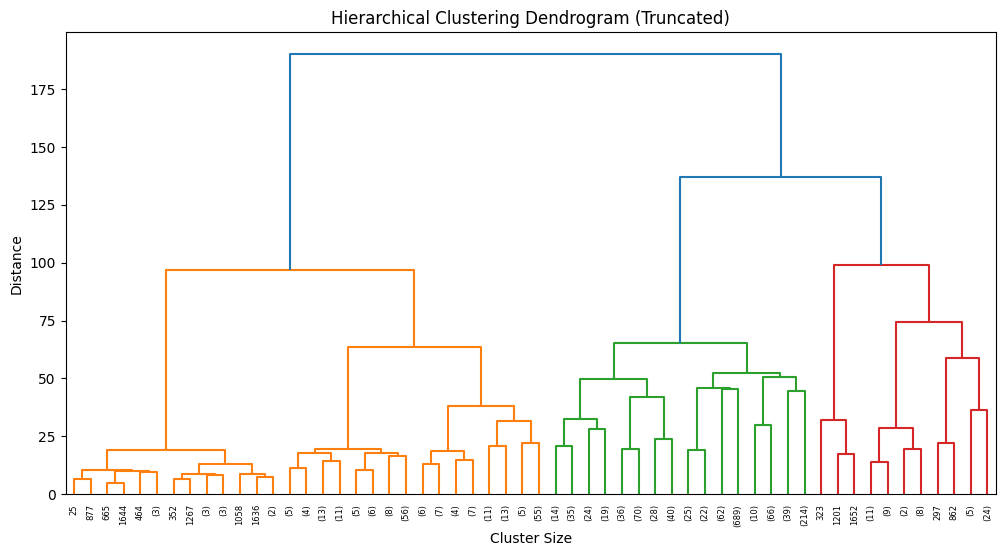

In [36]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(hybrid_matrix_weighted, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

In [41]:
import sys
!{sys.executable} -m pip install hdbscan

   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 671.8/671.8 kB 6.5 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
hdb_labels = clusterer.fit_predict(hybrid_matrix_weighted)

print("Unique HDBSCAN clusters:", np.unique(hdb_labels))

Unique HDBSCAN clusters: [-1]


In [43]:
models = {}

# KMeans (k=3)
km = KMeans(n_clusters=3, random_state=42)
km_labels = km.fit_predict(hybrid_matrix_weighted)
models["KMeans_3"] = silhouette_score(hybrid_matrix_weighted, km_labels)

# GMM (k=3)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(hybrid_matrix_weighted)
models["GMM_3"] = silhouette_score(hybrid_matrix_weighted, gmm_labels)

# HDBSCAN
if len(np.unique(hdb_labels)) > 1:
    models["HDBSCAN"] = silhouette_score(
        hybrid_matrix_weighted[hdb_labels != -1],
        hdb_labels[hdb_labels != -1]
    )

models

{'KMeans_3': np.float64(0.2201107262906002),
 'GMM_3': np.float64(-0.011011387666177338)}